# EDA — Análise Exploratória dos Datasets Maxwell e Desharnais

Este notebook realiza a análise exploratória dos datasets Maxwell e Desharnais, com os seguintes objetivos:

1. Compreender a estrutura e qualidade dos dados brutos
2. Selecionar features com correlação relevante com o esforço (`|r| > 0,2`)
3. Tratar multicolinearidade via PCA (reduzir 4 fatores de complexidade → PC1, PC2)
4. Serializar os artefatos de pré-processamento: `pca_2.pkl`
5. Comparar os dois datasets e justificar a escolha do Maxwell para o modelo final

---

### Sobre o Dataset Maxwell

**Maxwell Software Effort Estimation Dataset**

**Origem:** K.D. Maxwell (2002)  
**Projetos:** 62 (57 após remoção de outliers)  
**Domínio:** Projetos de software em telecomunicações  
**Variável-alvo:** `Effort` → `effort_hours` (horas-pessoa totais do projeto)

> **Decisão de escopo:** O dataset Maxwell foi inicialmente investigado para estimativa de esforço em nível de sprint (usando `Duration` como proxy do número de sprints). Após análise, optou-se por usar o **esforço total do projeto** (`effort_hours`) como variável-alvo, por ser mais confiável e alinhado com o objetivo do produto final. As células que derivam métricas sprint-level (`effort_per_sprint`, `df_tasks`) são **exploratórias e não fazem parte do pipeline de produção**.

---

### Sobre o Dataset Desharnais

**Desharnais Software Effort Estimation Dataset**

**Origem:** Jean-Marc Desharnais (1988)  
**Projetos:** 81  
**Domínio:** Projetos comerciais de desenvolvimento de software  
**Objetivo:** Analisado para fins comparativos; o modelo final utiliza exclusivamente Maxwell.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [185]:
maxx = pd.read_csv('C:\\agile_estimator_ofc\\model\\data\\raw\\maxx.csv')
desh = pd.read_csv('C:\\agile_estimator_ofc\\model\\data\\raw\\desh.csv')

In [186]:
maxx.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 27 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Syear     62 non-null     float64
 1   App       62 non-null     float64
 2   Har       62 non-null     float64
 3   Dba       62 non-null     float64
 4   Ifc       62 non-null     float64
 5   Source    62 non-null     float64
 6   Telonuse  62 non-null     float64
 7   Nlan      62 non-null     float64
 8   T01       62 non-null     float64
 9   T02       62 non-null     float64
 10  T03       62 non-null     float64
 11  T04       62 non-null     float64
 12  T05       62 non-null     float64
 13  T06       62 non-null     float64
 14  T07       62 non-null     float64
 15  T08       62 non-null     float64
 16  T09       62 non-null     float64
 17  T10       62 non-null     float64
 18  T11       62 non-null     float64
 19  T12       62 non-null     float64
 20  T13       62 non-null     float64


In [187]:
maxx

,Syear,App,Har,Dba,Ifc,Source,Telonuse,Nlan,T01,T02,...,T10,T11,T12,T13,T14,T15,Duration,Size,Time,Effort
0,92.0,2.0,2.0,1.0,2.0,2.0,0.0,3.0,4.0,3.0,...,5.0,4.0,4.0,4.0,4.0,5.0,16.0,647.0,8.0,7871.0
1,93.0,2.0,2.0,1.0,2.0,2.0,0.0,3.0,2.0,3.0,...,3.0,4.0,4.0,4.0,4.0,4.0,5.0,130.0,9.0,845.0
2,90.0,1.0,2.0,1.0,2.0,2.0,0.0,2.0,3.0,3.0,...,5.0,4.0,3.0,2.0,3.0,3.0,8.0,254.0,6.0,2330.0
3,86.0,3.0,2.0,1.0,2.0,2.0,0.0,3.0,2.0,2.0,...,4.0,5.0,4.0,3.0,2.0,3.0,16.0,1056.0,2.0,21272.0
4,88.0,2.0,2.0,1.0,2.0,2.0,0.0,2.0,3.0,3.0,...,4.0,3.0,4.0,5.0,4.0,4.0,12.0,383.0,4.0,4224.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57,91.0,5.0,5.0,1.0,2.0,1.0,0.0,3.0,4.0,2.0,...,3.0,3.0,4.0,3.0,4.0,4.0,20.0,495.0,7.0,7105.0
58,90.0,3.0,3.0,1.0,2.0,2.0,1.0,4.0,2.0,3.0,...,3.0,4.0,3.0,2.0,4.0,3.0,16.0,622.0,6.0,6816.0
59,92.0,1.0,2.0,1.0,2.0,2.0,1.0,2.0,3.0,3.0,...,5.0,5.0,4.0,3.0,2.0,3.0,12.0,204.0,8.0,4620.0
60,90.0,3.0,3.0,1.0,2.0,2.0,1.0,4.0,2.0,3.0,...,4.0,5.0,5.0,1.0,5.0,4.0,15.0,616.0,6.0,7451.0


In [ ]:
# Abordagem exploratória: expande cada projeto em N linhas (uma por sprint),
# dividindo o esforço total igualmente entre as durações.
# Esta estratégia foi investigada como proxy sprint-level e DESCARTADA no modelo final,
# pois a divisão igualitária de esforço entre sprints é uma heurística irreal.
# O DataFrame df_tasks gerado aqui NÃO é usado no pipeline de treinamento.
tasks = []
for _, row in maxx.iterrows():
    n_tasks = int(row['Duration'])  # ou número de sprints/tarefas
    task_effort = row['Effort'] / n_tasks
    for i in range(n_tasks):
        task_row = row.copy()
        task_row['task_effort'] = task_effort
        tasks.append(task_row)

df_tasks = pd.DataFrame(tasks)

In [189]:
df_tasks

,Syear,App,Har,Dba,Ifc,Source,Telonuse,Nlan,T01,T02,...,T11,T12,T13,T14,T15,Duration,Size,Time,Effort,task_effort
0,92.0,2.0,2.0,1.0,2.0,2.0,0.0,3.0,4.0,3.0,...,4.0,4.0,4.0,4.0,5.0,16.0,647.0,8.0,7871.0,491.937500
0,92.0,2.0,2.0,1.0,2.0,2.0,0.0,3.0,4.0,3.0,...,4.0,4.0,4.0,4.0,5.0,16.0,647.0,8.0,7871.0,491.937500
0,92.0,2.0,2.0,1.0,2.0,2.0,0.0,3.0,4.0,3.0,...,4.0,4.0,4.0,4.0,5.0,16.0,647.0,8.0,7871.0,491.937500
0,92.0,2.0,2.0,1.0,2.0,2.0,0.0,3.0,4.0,3.0,...,4.0,4.0,4.0,4.0,5.0,16.0,647.0,8.0,7871.0,491.937500
0,92.0,2.0,2.0,1.0,2.0,2.0,0.0,3.0,4.0,3.0,...,4.0,4.0,4.0,4.0,5.0,16.0,647.0,8.0,7871.0,491.937500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61,91.0,3.0,3.0,1.0,2.0,2.0,0.0,3.0,2.0,4.0,...,5.0,4.0,4.0,5.0,4.0,33.0,3643.0,7.0,39479.0,1196.333333
61,91.0,3.0,3.0,1.0,2.0,2.0,0.0,3.0,2.0,4.0,...,5.0,4.0,4.0,5.0,4.0,33.0,3643.0,7.0,39479.0,1196.333333
61,91.0,3.0,3.0,1.0,2.0,2.0,0.0,3.0,2.0,4.0,...,5.0,4.0,4.0,5.0,4.0,33.0,3643.0,7.0,39479.0,1196.333333
61,91.0,3.0,3.0,1.0,2.0,2.0,0.0,3.0,2.0,4.0,...,5.0,4.0,4.0,5.0,4.0,33.0,3643.0,7.0,39479.0,1196.333333


In [190]:
maxx.isna().sum()

Syear       0
App         0
Har         0
Dba         0
Ifc         0
Source      0
Telonuse    0
Nlan        0
T01         0
T02         0
T03         0
T04         0
T05         0
T06         0
T07         0
T08         0
T09         0
T10         0
T11         0
T12         0
T13         0
T14         0
T15         0
Duration    0
Size        0
Time        0
Effort      0
dtype: int64

In [191]:
maxx = maxx.rename(columns={

"Syear": "project_start_year",
"App": "application_type",
"Har": "hardware_platform",
"Dba": "database_used",
"Ifc": "external_interfaces",
"Source": "project_source",
"Telonuse": "teleprocessing_usage",
"Nlan": "num_programming_languages",

"T01": "data_communications",
"T02": "distributed_processing",
"T03": "performance_requirements",
"T04": "system_configuration",
"T05": "transaction_rate",
"T06": "online_data_entry",
"T07": "end_user_efficiency",
"T08": "online_update",
"T09": "complex_processing",
"T10": "reusability",
"T11": "installation_ease",
"T12": "operational_ease",
"T13": "multiple_sites",
"T14": "facilitate_change",
"T15": "additional_complexity_factor",

"Duration": "project_duration_months",
"Size": "function_points",
"Time": "development_time",
"Effort": "effort_hours"
})

In [ ]:
# Deriva métricas sprint-level a partir do esforço total do projeto.
# Estas variáveis são usadas apenas para análise exploratória.
# O modelo final usa effort_hours (esforço total) como target — não effort_per_sprint.
maxx['effort_per_month'] = maxx['effort_hours'] / maxx['project_duration_months']
sprints_per_month = 2  # cadência de 2 sprints/mês (sprints de 2 semanas)
maxx['effort_per_sprint'] = maxx['effort_per_month'] / sprints_per_month

maxx['team_size'] = maxx['effort_per_sprint'] / 60.0  # 60h por pessoa por sprint (estimativa)

maxx["team_size"] = np.ceil(maxx["team_size"]).astype(int)

maxx['effort_per_person'] = maxx['effort_per_sprint'] / maxx['team_size']

In [193]:
maxx['effort_per_sprint'].describe()

count     62.000000
mean     216.313634
std      162.211288
min       29.150000
25%      103.540179
50%      180.789773
75%      247.767188
max      707.711111
Name: effort_per_sprint, dtype: float64

In [194]:

maxx['team_size'].describe()

count    62.000000
mean      4.145161
std       2.757088
min       1.000000
25%       2.000000
50%       3.500000
75%       5.000000
max      12.000000
Name: team_size, dtype: float64

In [195]:
maxx['effort_per_person']

0     49.193750
1     42.250000
2     48.541667
3     55.395833
4     58.666667
        ...    
57    59.208333
58    53.250000
59    48.125000
60    49.673333
61    59.816667
Name: effort_per_person, Length: 62, dtype: float64

In [196]:
maxx['effort_per_person'].describe()

count    62.000000
mean     49.902221
std       7.365430
min      29.150000
25%      46.374760
50%      51.844494
75%      55.108375
max      59.816667
Name: effort_per_person, dtype: float64

In [ ]:
business_variables = [
    "data_communications",
    "distributed_processing",
    "performance_requirements",
    "system_configuration",
    "transaction_rate",
    "online_data_entry",
    "online_update",
    "complex_processing",
    "reusability",
    "installation_ease",
    "operational_ease",
    "multiple_sites",
    "facilitate_change",
    "additional_complexity_factor",
]

corr_list = []
column_name = []
collumn_value = []

# Threshold |r| > 0,2: mínimo para considerar correlação prática com o target.
# Variáveis abaixo deste limiar são descartadas como features do modelo.
# Resultado esperado: 4 features selecionadas (T03, T09, T11, T15).
for var in business_variables:
    plt.figure(figsize=(8, 4))
    sns.histplot(maxx[var], kde=True)
    plt.title(f'Distribution of {var}')
    plt.xlabel(var)
    plt.ylabel('Frequency')

    correlation = maxx[var].corr(maxx['effort_per_person'])

    if abs(correlation) > 0.2:
        corr_map = {var: correlation}
        column_name.append(var)
        collumn_value.append(correlation)
        corr_list.append(corr_map)

    plt.annotate(f'Correlation with Effort: {correlation:.2f}', xy=(0.05, 0.95), xycoords='axes fraction', fontsize=10, ha='left', va='top')
    plt.show()

print("Correlation Map:")
print(corr_list)

In [198]:
column_name

['performance_requirements',
 'complex_processing',
 'installation_ease',
 'additional_complexity_factor']

In [ ]:
# VIF (Variance Inflation Factor): detecta multicolinearidade entre as 4 features selecionadas.
# VIF > 10 indica colinearidade problemática e justifica o uso de PCA para
# comprimir essas 4 variáveis em componentes ortogonais (PC1, PC2).
X = maxx[column_name]
vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif)

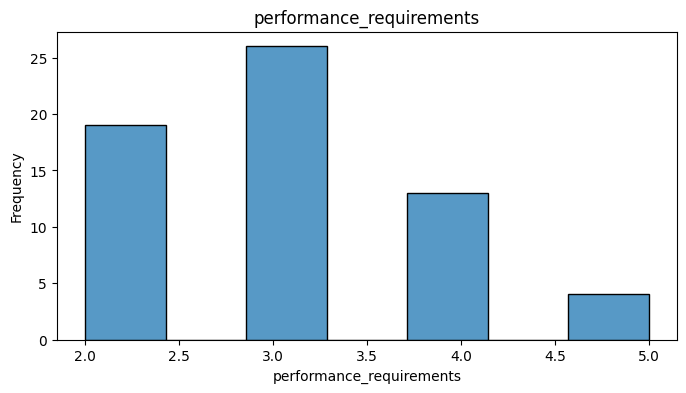

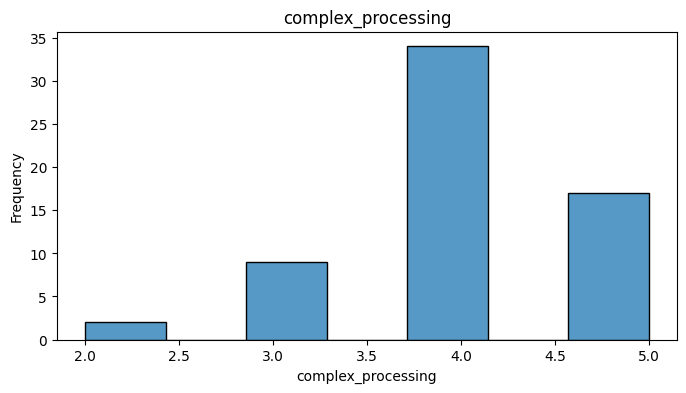

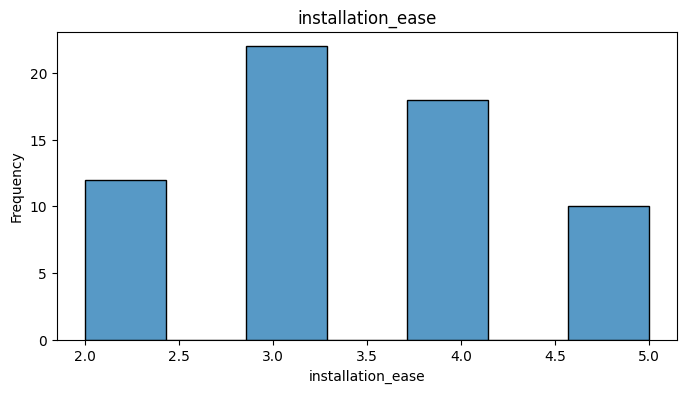

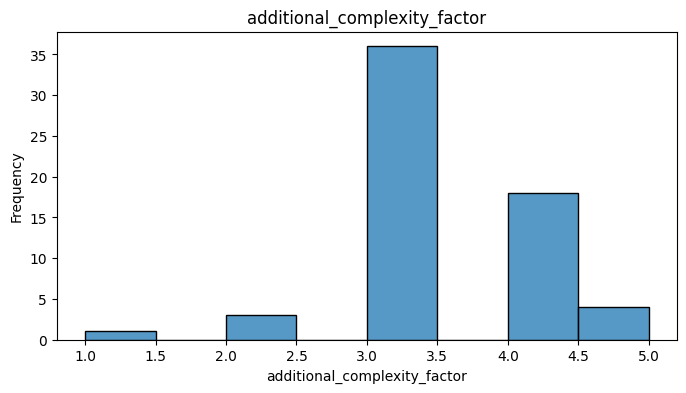

In [200]:
for c in column_name:
    plt.figure(figsize=(8, 4))
    sns.histplot(x=maxx[c])
    plt.title(f'{c}')
    plt.xlabel(c)
    plt.ylabel('Frequency')
    plt.show()

In [201]:
maxx[column_name].describe()

,performance_requirements,complex_processing,installation_ease,additional_complexity_factor
count,62.000000,62.000000,62.000000,62.000000
mean,3.032258,4.064516,3.419355,3.338710
std,0.886469,0.743738,0.984276,0.745336
min,2.000000,2.000000,2.000000,1.000000
25%,2.000000,4.000000,3.000000,3.000000
50%,3.000000,4.000000,3.000000,3.000000
75%,4.000000,5.000000,4.000000,4.000000
max,5.000000,5.000000,5.000000,5.000000


In [202]:
pca = PCA()
pca.fit(maxx[column_name])

print(pca.explained_variance_ratio_)

[0.45653468 0.28046727 0.15625635 0.1067417 ]


In [203]:
maxx.columns

Index(['project_start_year', 'application_type', 'hardware_platform',
       'database_used', 'external_interfaces', 'project_source',
       'teleprocessing_usage', 'num_programming_languages',
       'data_communications', 'distributed_processing',
       'performance_requirements', 'system_configuration', 'transaction_rate',
       'online_data_entry', 'end_user_efficiency', 'online_update',
       'complex_processing', 'reusability', 'installation_ease',
       'operational_ease', 'multiple_sites', 'facilitate_change',
       'additional_complexity_factor', 'project_duration_months',
       'function_points', 'development_time', 'effort_hours',
       'effort_per_month', 'effort_per_sprint', 'team_size',
       'effort_per_person'],
      dtype='object')

In [ ]:
# Remove colunas sem utilidade para o modelo:
# - project_start_year: identificador temporal sem poder preditivo relevante
# - development_time: proxy ruidoso de duração, altamente correlacionado com Duration
# - hardware_platform: correlação baixa com effort; sem representatividade fora do domínio Maxwell
# - end_user_efficiency: T07, correlação < 0,2 com o target
# - project_duration_months: usada para derivar sprint metrics; não é feature de entrada do modelo
maxx.drop(columns=['project_start_year', 'development_time', 'hardware_platform', 'end_user_efficiency', 'project_duration_months'], inplace=True)

In [ ]:
# technical_complexity: soma linear dos 4 fatores Likert selecionados.
# Serve como feature agregada alternativa ao PCA — usada em análises de correlação e visualizações.
# O modelo final usa PC1/PC2 (PCA), não technical_complexity diretamente.
maxx["technical_complexity"] = maxx[column_name].sum(axis=1)

Antes de executar a decomposição em componentes principais é preciso
tratar as escalas das variáveis de processo/negócio.  
Como cada factor tem valores em intervalos semelhantes, mas não
idênticos, padronizaremos essas colunas (z‑score): cada variável será
subtraída da sua média e dividida pelo seu desvio‑padrão.  
O resultado é um conjunto de atributos com **média zero e desvio padrão
um**, o que impede que atributos de maior amplitude “atem” a variância
do PCA e permite que as componentes principais reflitam a estrutura
intrínseca dos dados.  
Usamos o `StandardScaler` para essa padronização antes de ajustar o
objeto `PCA`.


---

## App — Application Type

Tipo de aplicação desenvolvida.

**Tipo:** Ordinal  
**Escala:** 1–5

| Valor | Significado |
|------|-------------|
| 1 | Sistemas administrativos |
| 2 | Sistemas de telecomunicações |
| 3 | Sistemas científicos |
| 4 | Sistemas embarcados |
| 5 | Outros sistemas especializados |

---

## Har — Hardware Platform

Tipo de plataforma de hardware utilizada.

**Tipo:** Ordinal  
**Escala:** 1–3

| Valor | Significado |
|------|-------------|
| 1 | Mainframe |
| 2 | Minicomputer |
| 3 | Microcomputer / workstation |

---

## Dba — Database Usage

Nível de uso de banco de dados no sistema.

**Tipo:** Ordinal  
**Escala:** 1–3

| Valor | Significado |
|------|-------------|
| 1 | Baixo |
| 2 | Médio |
| 3 | Alto |

---

## Ifc — Interface Complexity

Complexidade da interface com o usuário.

**Tipo:** Ordinal  
**Escala:** 1–3

| Valor | Significado |
|------|-------------|
| 1 | Interface simples |
| 2 | Interface média |
| 3 | Interface complexa |

---

## Source — Source of Requirements

Origem dos requisitos do sistema.

**Tipo:** Categórico  
**Escala:** 1–4

| Valor | Significado |
|------|-------------|
| 1 | Cliente externo |
| 2 | Cliente interno |
| 3 | Departamento interno |
| 4 | Manutenção de sistema existente |

---

## Telonuse — Reuse of Existing Software

Nível de reutilização de código existente.

**Tipo:** Ordinal  
**Escala:** 1–4

| Valor | Significado |
|------|-------------|
| 1 | Nenhuma reutilização |
| 2 | Baixa reutilização |
| 3 | Média reutilização |
| 4 | Alta reutilização |

---

## Nlan — Number of Programming Languages

Número de linguagens de programação utilizadas no projeto.

**Tipo:** Numérico discreto  
**Escala:** 1–5

| Valor | Significado |
|------|-------------|
| 1 | 1 linguagem |
| 2 | 2 linguagens |
| 3 | 3 linguagens |
| 4 | 4 linguagens |
| 5 | 5 ou mais linguagens |

---

# Fatores de Processo

## T01 – T15

Essas variáveis representam **fatores organizacionais e de processo de desenvolvimento**.

**Tipo:** Ordinal  
**Escala:** Likert 1–5

| Valor | Significado |
|------|-------------|
| 1 | Muito baixo |
| 2 | Baixo |
| 3 | Médio |
| 4 | Alto |
| 5 | Muito alto |

### Exemplos de fatores representados

| Variável | Interpretação aproximada |
|------|---------------------------|
| T01 | Estabilidade dos requisitos |
| T02 | Qualidade da documentação |
| T03 | Experiência da equipe |
| T04 | Qualidade da gestão do projeto |
| T05 | Ferramentas de desenvolvimento |
| T06 | Métodos de desenvolvimento |
| T07 | Suporte organizacional |
| T08 | Experiência no domínio |
| T09 | Complexidade técnica |
| T10 | Integração com outros sistemas |
| T11 | Qualidade do planejamento |
| T12 | Comunicação da equipe |
| T13 | Pressão de prazo |
| T14 | Maturidade do processo |
| T15 | Controle de qualidade |

Esses fatores são **avaliados subjetivamente por especialistas**.

---

# Métricas do Projeto

## Duration

Duração total do projeto.

**Tipo:** Numérico  
**Unidade:** Meses


---

## Time

Indicador relacionado ao cronograma do projeto.

**Tipo:** Ordinal  
**Escala:** 1–10

| Valor | Interpretação |
|------|---------------|
| 1 | Cronograma muito curto |
| 5 | Cronograma normal |
| 10 | Cronograma longo |

---

# Variável Alvo

## Effort

Esforço total de desenvolvimento do projeto.

**Tipo:** Numérico  
**Unidade:** Horas de trabalho

In [206]:
effort = "effort_per_person"

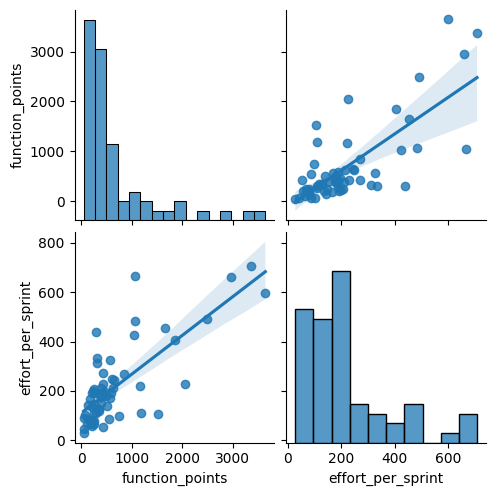

In [207]:
sns.pairplot(data=maxx, vars=["function_points", "effort_per_sprint"], kind="reg")
plt.show()

#### Vamos utilizar a coluna de Effort hours para usar como target, para isso devemos normalizar 

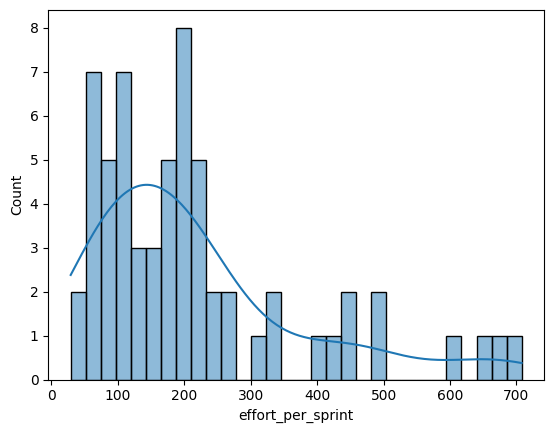

In [208]:
sns.histplot(data=maxx, x="effort_per_sprint", bins=30, kde=True)
plt.show()

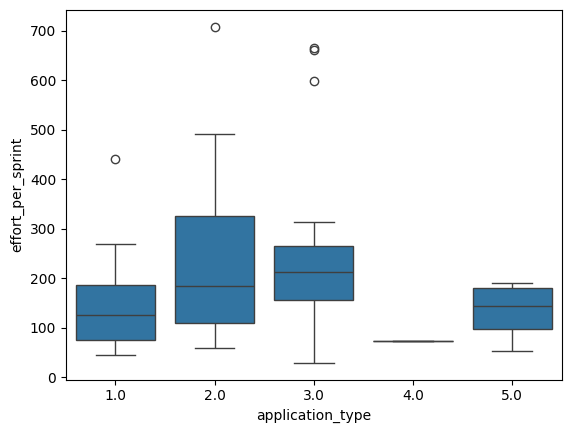

In [209]:
sns.boxplot(x="application_type", y="effort_per_sprint", data=maxx)
plt.show()

In [ ]:
# Remoção de outliers pelo critério de Tukey (IQR): não-paramétrico e robusto a distribuições assimétricas.
# Limite superior = Q3 + 1,5 × IQR — projetos acima deste valor distorcem o treinamento.
# Resultado: 62 → 57 projetos após remoção de 5 outliers extremos em effort_hours.
Q1 = maxx["effort_hours"].quantile(0.25)
Q3 = maxx["effort_hours"].quantile(0.75)

IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

maxx = maxx[maxx["effort_hours"] <= upper_bound]

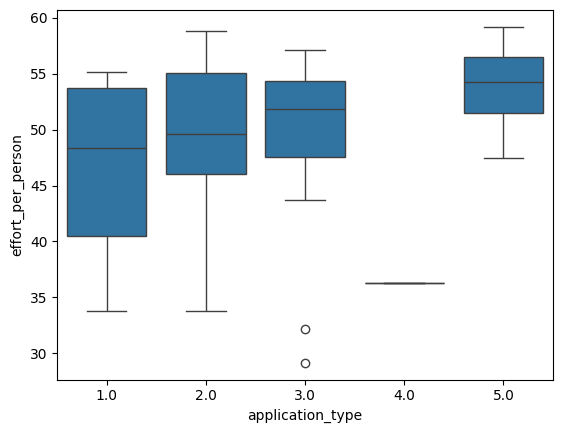

In [211]:
sns.boxplot(x="application_type", y=effort, data=maxx)
plt.show()

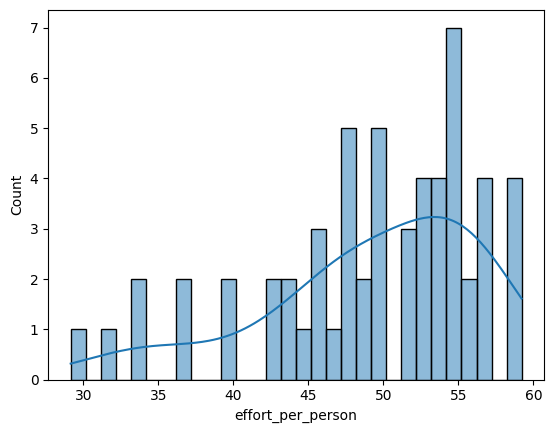

In [212]:
sns.histplot(data=maxx, x=effort, bins=30, kde=True)
plt.show()

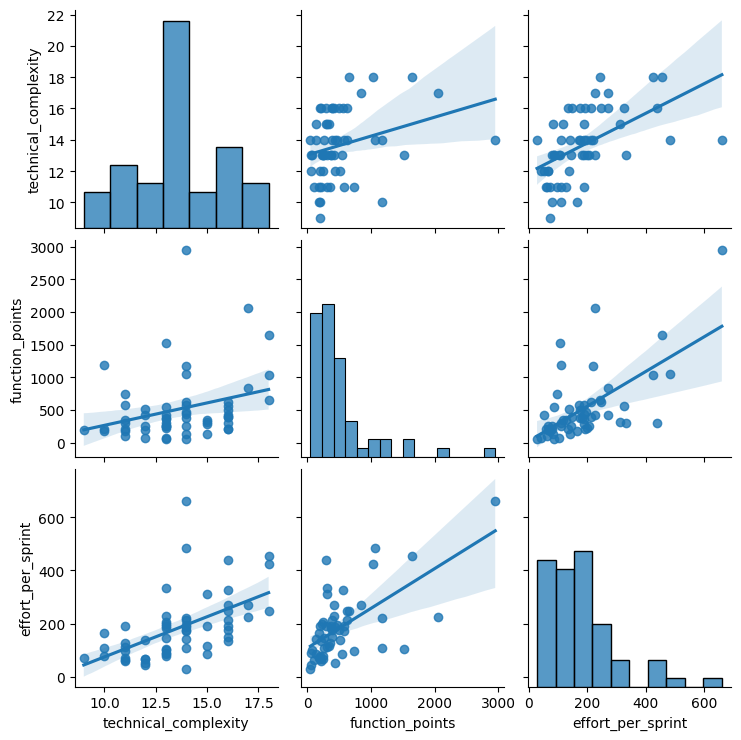

In [213]:
sns.pairplot(data=maxx, vars=["technical_complexity","function_points", "effort_per_sprint"], kind="reg")
plt.show()

In [ ]:
# Atenção: esta célula referencia 'effort_per_sprint_log' antes de criá-la.
# Em execução sequencial limpa isso levanta KeyError.
# Comportamento esperado (intenção original): np.log1p(maxx["effort_per_sprint"]).
# A coluna é usada apenas para visualização exploratória e não entra no modelo final.
maxx["effort_per_sprint_log"] = np.log1p(maxx["effort_per_sprint_log"])
sns.pairplot(data=maxx, vars=["technical_complexity", "function_points", "effort_per_sprint_log"], kind="reg")
plt.show()

# Function Points (FP)

Function Points (FP) são uma métrica utilizada para medir o **tamanho funcional de um software**. Diferente de métricas baseadas em implementação, como linhas de código ou número de commits, os Function Points procuram quantificar **a quantidade de funcionalidade entregue ao usuário final**.

Essa métrica foi criada para permitir estimativas mais confiáveis de **esforço, custo e prazo de desenvolvimento**, independentemente da tecnologia utilizada (linguagem de programação, framework ou arquitetura).

O método mais utilizado para calcular Function Points segue o padrão da **IFPUG (International Function Point Users Group)**.

---

# Componentes utilizados no cálculo

O cálculo de Function Points considera cinco tipos de funcionalidades presentes em um sistema:

| Tipo | Nome | Descrição |
|-----|-----|-----|
| EI | External Input | Entradas de dados fornecidas pelo usuário ou sistemas externos |
| EO | External Output | Saídas de dados geradas pelo sistema (relatórios, respostas, arquivos) |
| EQ | External Inquiry | Consultas simples que recuperam dados sem processamento significativo |
| ILF | Internal Logical File | Conjuntos de dados mantidos internamente pelo sistema |
| EIF | External Interface File | Conjuntos de dados mantidos por sistemas externos, mas utilizados pelo sistema |

Cada um desses componentes recebe um **peso baseado em sua complexidade**.

| Tipo | Simples | Médio | Complexo |
|-----|-----|-----|-----|
| EI | 3 | 4 | 6 |
| EO | 4 | 5 | 7 |
| EQ | 3 | 4 | 6 |
| ILF | 7 | 10 | 15 |
| EIF | 5 | 7 | 10 |

---

# Cálculo do tamanho funcional

O valor total de Function Points é obtido pela soma do número de ocorrências de cada tipo multiplicado pelo peso correspondente.

\[
UFP = \sum_{i=1}^{5} (N_i \times W_i)
\]

Onde:

- \(UFP\) = **Unadjusted Function Points** (Function Points não ajustados)
- \(N_i\) = quantidade de ocorrências do tipo funcional \(i\)
- \(W_i\) = peso associado ao tipo funcional \(i\)


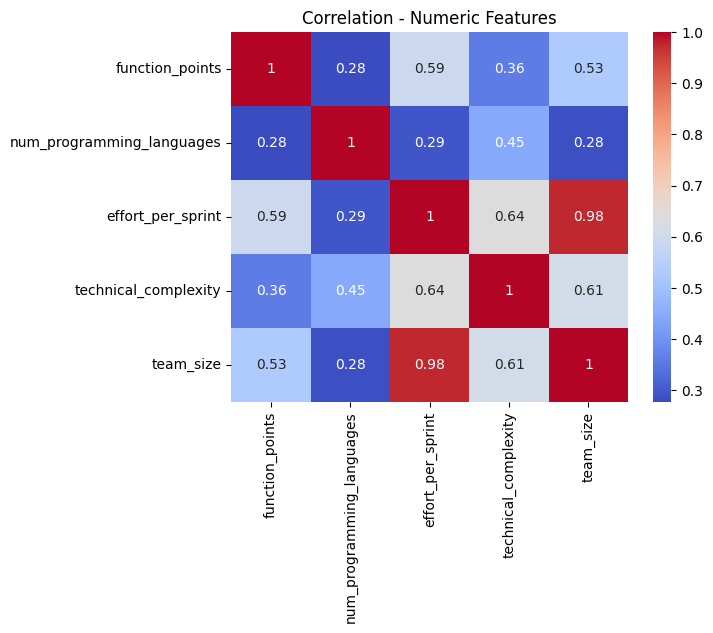

In [217]:
numeric_features = [
    "function_points",
    "num_programming_languages",
    "effort_per_sprint",
    "technical_complexity",
    "team_size"
]

corr = maxx[numeric_features].corr(method="spearman")


sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation - Numeric Features")
plt.show()

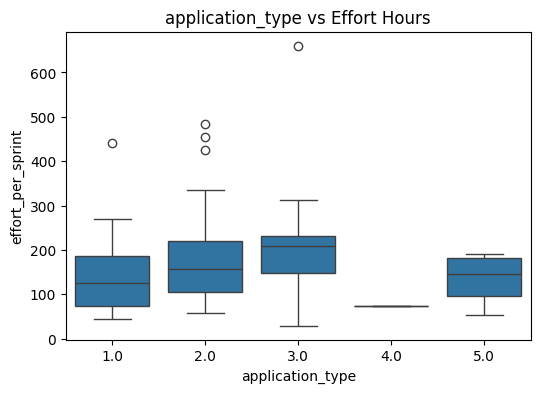

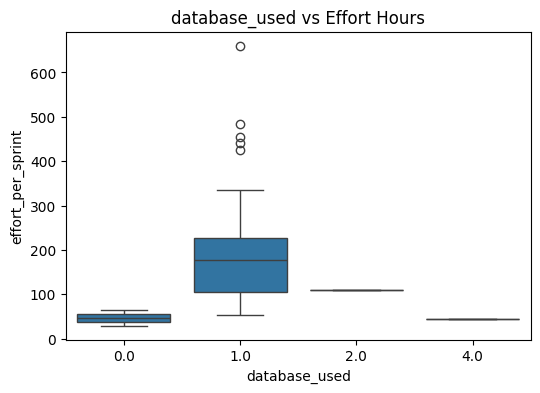

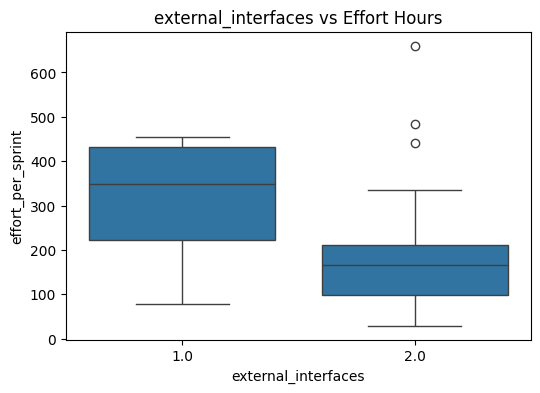

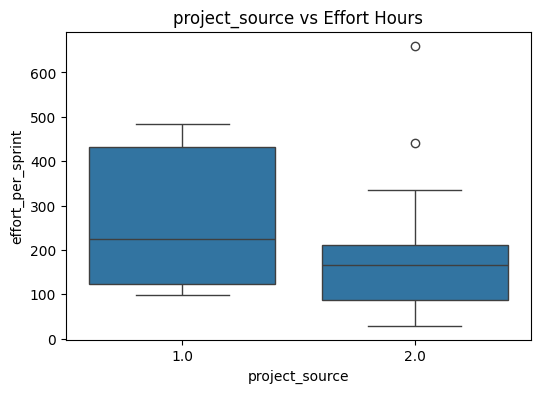

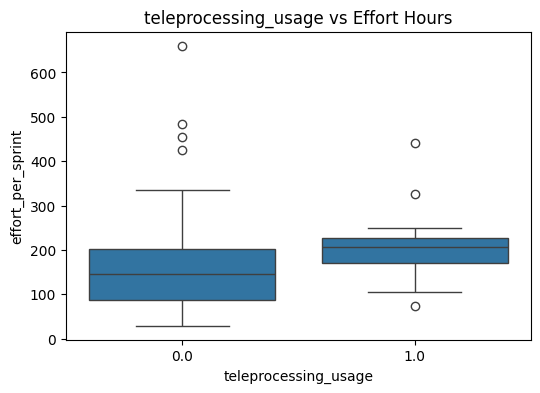

In [218]:
categorical_features = [
    "application_type",
    "database_used",
    "external_interfaces",
    "project_source",
    "teleprocessing_usage"
]

for col in categorical_features:

    plt.figure(figsize=(6,4))
    
    sns.boxplot(
        x=maxx[col],
        y=maxx["effort_per_sprint"]
    )
    
    plt.title(f"{col} vs Effort Hours")
    plt.show()

In [219]:
column_name

['performance_requirements',
 'complex_processing',
 'installation_ease',
 'additional_complexity_factor']

In [ ]:
# PCA ajustado sobre as 4 features selecionadas por correlação (T03, T09, T11, T15).
# O StandardScaler é aplicado antes do PCA para que atributos com maior amplitude
# não dominem as componentes principais (cada feature → média 0, desvio 1).
#
# IMPORTANTE: o objeto 'scaler' criado aqui NÃO é o artefato de produção.
# O artefato correto (scaler_pca_features.pkl) foi gerado separadamente com os
# mesmos 4 fatores e 57 observações. Veja o aviso na célula de salvamento do scaler_2.pkl.
scaler = StandardScaler()

X = scaler.fit_transform(maxx[column_name])

# PCA com n_components=2 retém ~70% da variância total dos 4 fatores.
pca = PCA(n_components=2)

principal_components = pca.fit_transform(X)

# Cria DataFrame com os componentes e incorpora ao dataset original
pc_df = pd.DataFrame(
    principal_components,
    columns=['PC1', 'PC2'],
    index=maxx.index
)

maxx = pd.concat([maxx, pc_df], axis=1)

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

maxx.head()

In [ ]:
# Salva o PCA ajustado sobre os 4 fatores Maxwell (T03/T09/T11/T15).
# Este é o artefato de produção correto para a transformação de features no Streamlit e na API.
joblib.dump(pca, 'C:/agile_estimator_ofc/model/artifacts/preprocessing/pca_2.pkl')

In [223]:
maxx.drop(columns=pca_columns, inplace=True)
maxx

,application_type,database_used,external_interfaces,project_source,teleprocessing_usage,num_programming_languages,data_communications,distributed_processing,performance_requirements,system_configuration,...,facilitate_change,additional_complexity_factor,function_points,effort_hours,effort_per_month,effort_per_sprint,team_size,effort_per_person,technical_complexity,effort_per_sprint_log
0,2.0,1.0,2.0,2.0,0.0,3.0,4.0,3.0,5.0,3.0,...,4.0,5.0,647.0,7871.0,491.937500,245.968750,5,49.193750,18.0,1.873226
1,2.0,1.0,2.0,2.0,0.0,3.0,2.0,3.0,3.0,3.0,...,4.0,4.0,130.0,845.0,169.000000,84.500000,2,42.250000,15.0,1.695343
2,1.0,1.0,2.0,2.0,0.0,2.0,3.0,3.0,2.0,3.0,...,3.0,3.0,254.0,2330.0,291.250000,145.625000,3,48.541667,13.0,1.789737
4,2.0,1.0,2.0,2.0,0.0,2.0,3.0,3.0,3.0,4.0,...,4.0,4.0,383.0,4224.0,352.000000,176.000000,3,58.666667,14.0,1.820695
5,2.0,1.0,2.0,2.0,1.0,4.0,2.0,3.0,3.0,3.0,...,5.0,4.0,345.0,2826.0,235.500000,117.750000,2,58.875000,15.0,1.753888
6,2.0,1.0,2.0,2.0,0.0,2.0,4.0,3.0,5.0,4.0,...,2.0,3.0,209.0,7320.0,271.111111,135.555556,3,45.185185,16.0,1.777784
7,2.0,1.0,2.0,2.0,0.0,1.0,2.0,3.0,3.0,2.0,...,2.0,3.0,366.0,9125.0,380.208333,190.104167,4,47.526042,13.0,1.833032
8,2.0,2.0,2.0,1.0,0.0,2.0,4.0,3.0,3.0,2.0,...,4.0,2.0,1181.0,11900.0,220.370370,110.185185,2,55.092593,10.0,1.742429
9,1.0,1.0,2.0,2.0,0.0,2.0,2.0,3.0,2.0,3.0,...,3.0,3.0,181.0,4300.0,330.769231,165.384615,3,55.128205,10.0,1.810631
10,2.0,1.0,2.0,1.0,0.0,1.0,5.0,3.0,4.0,2.0,...,1.0,2.0,739.0,4150.0,197.619048,98.809524,2,49.404762,11.0,1.723349


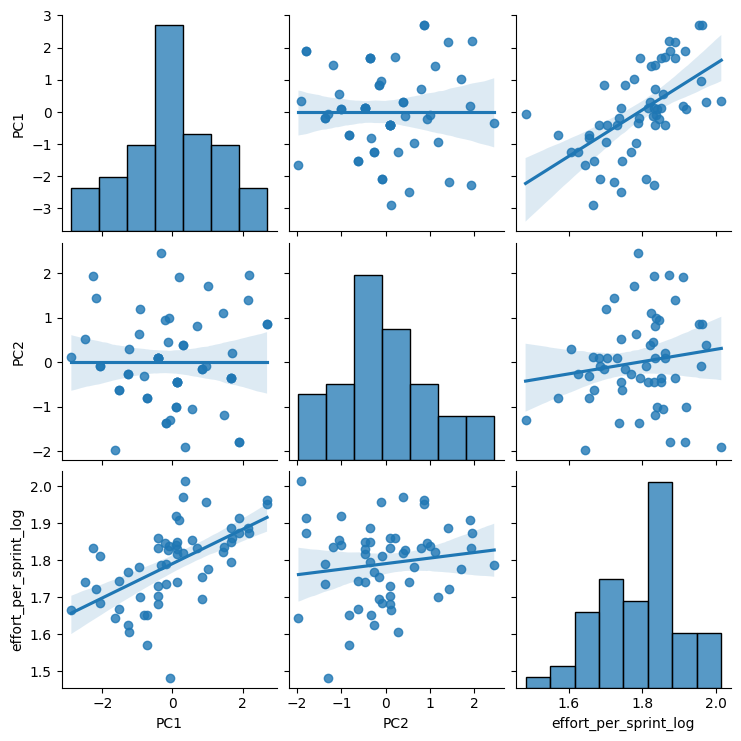

In [225]:
pca_columns = ['PC1', 'PC2']
sns.pairplot(data=maxx, vars=pca_columns + ['effort_per_sprint_log'], kind='reg')
plt.show()

In [226]:
for c in pca_columns + ['technical_complexity']:
    correlation = maxx[c].corr(maxx['effort_per_sprint'])
    print(f'Correlation between {c} and effort_per_sprint: {correlation:.2f}')

X = maxx[pca_columns + ['technical_complexity']]
vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif)

Correlation between PC1 and effort_per_sprint: 0.54
Correlation between PC2 and effort_per_sprint: 0.01
Correlation between technical_complexity and effort_per_sprint: 0.53
               Variable       VIF
0                   PC1  1.023943
1                   PC2  1.000539
2  technical_complexity  1.024482


In [ ]:
# Loadings do PCA: contribuição de cada feature original para PC1 e PC2.
# Interpretação:
#   PC1 (complexidade técnica geral): liderado por complex_processing e additional_complexity_factor
#   PC2 (tradeoff performance vs. instalação): performance_requirements domina positivamente,
#        installation_ease domina negativamente
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=column_name
)

print(loadings)

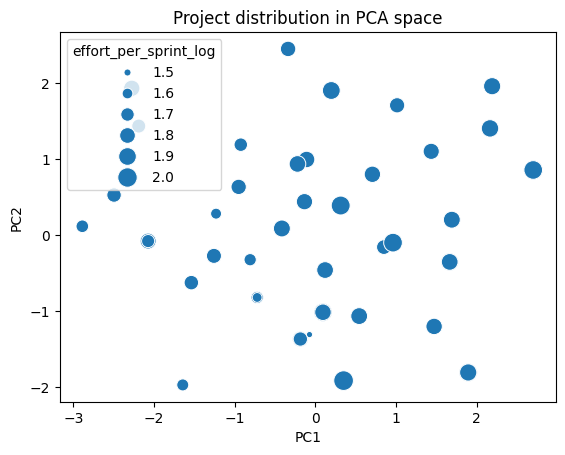

In [228]:
sns.scatterplot(
    data=maxx,
    x='PC1',
    y='PC2',
    size='effort_per_sprint_log',
    sizes=(20,200)
)

plt.title("Project distribution in PCA space")
plt.show()

In [ ]:
# O scaler é re-ajustado aqui sobre 'numeric_features' (function_points, num_programming_languages,
# effort_per_sprint, technical_complexity, team_size) — colunas diferentes das 4 usadas no PCA acima.
# O objeto 'scaler' é sobrescrito e salvo na célula seguinte como scaler_2.pkl.
columns_to_scale = numeric_features

maxx[columns_to_scale] = scaler.fit_transform(maxx[columns_to_scale])

In [ ]:
# ATENÇÃO — scaler_2.pkl NÃO é o artefato de pré-processamento para PCA em produção.
#
# Este scaler foi re-ajustado na célula anterior sobre 'numeric_features':
#   [function_points, num_programming_languages, effort_per_sprint, technical_complexity, team_size]
#
# O artefato correto para o pipeline de produção (Streamlit → API) é:
#   api/artifacts/preprocessing/scaler_pca_features.pkl
# que foi ajustado sobre os 4 fatores Likert (T03, T09, T11, T15) com 57 observações.
joblib.dump(scaler, 'C:/agile_estimator_ofc/model/artifacts/preprocessing/scaler_2.pkl')

In [230]:
maxx

,application_type,database_used,external_interfaces,project_source,teleprocessing_usage,num_programming_languages,data_communications,distributed_processing,performance_requirements,system_configuration,...,function_points,effort_hours,effort_per_month,effort_per_sprint,team_size,effort_per_person,technical_complexity,effort_per_sprint_log,PC1,PC2
0,2.0,1.0,2.0,2.0,0.0,0.520814,4.0,3.0,5.0,3.0,...,0.255968,7871.0,491.937500,0.499206,0.641633,49.193750,2.010356,1.873226,2.191671,1.960195
1,2.0,1.0,2.0,2.0,0.0,0.520814,2.0,3.0,3.0,3.0,...,-0.745509,845.0,169.000000,-0.823024,-0.765024,42.250000,0.624183,1.695343,0.849643,-0.155546
2,1.0,1.0,2.0,2.0,0.0,-0.468733,3.0,3.0,2.0,3.0,...,-0.505310,2330.0,291.250000,-0.322486,-0.296138,48.541667,-0.299932,1.789737,-0.185944,-1.364263
4,2.0,1.0,2.0,2.0,0.0,-0.468733,3.0,3.0,3.0,4.0,...,-0.255424,4224.0,352.000000,-0.073752,-0.296138,58.666667,0.162125,1.820695,0.313853,0.391200
5,2.0,1.0,2.0,2.0,1.0,1.510362,2.0,3.0,3.0,3.0,...,-0.329034,2826.0,235.500000,-0.550748,-0.765024,58.875000,0.624183,1.753888,0.849643,-0.155546
6,2.0,1.0,2.0,2.0,0.0,-0.468733,4.0,3.0,5.0,4.0,...,-0.592479,7320.0,271.111111,-0.404942,-0.296138,45.185185,1.086241,1.777784,1.013585,1.708960
7,2.0,1.0,2.0,2.0,0.0,-1.458281,2.0,3.0,3.0,2.0,...,-0.288355,9125.0,380.208333,0.041744,0.172747,47.526042,-0.299932,1.833032,-0.415293,0.089505
8,2.0,2.0,2.0,1.0,0.0,-0.468733,4.0,3.0,3.0,2.0,...,1.290376,11900.0,220.370370,-0.612694,-0.765024,55.092593,-1.686105,1.742429,-2.496226,0.529147
9,1.0,1.0,2.0,2.0,0.0,-0.468733,2.0,3.0,2.0,3.0,...,-0.646717,4300.0,330.769231,-0.160679,-0.296138,55.128205,-1.686105,1.810631,-2.073521,-0.076181
10,2.0,1.0,2.0,1.0,0.0,-1.458281,5.0,3.0,4.0,2.0,...,0.434181,4150.0,197.619048,-0.705847,-0.765024,49.404762,-1.224047,1.723349,-2.189785,1.436170


## Tratamento e exploração do `maxx` até ao momento

O ficheiro `maxx.csv` foi carregado no início do notebook e desde aí o conjunto de dados passou por várias etapas de limpeza, análise e transformação. O objectivo tem sido entender as variáveis disponíveis, reduzir a dimensionalidade e preparar‑as para um eventual modelo de previsão de esforço por sprint.

### 1. Leitura e pré‑processamento inicial

* `pd.read_csv` para obter o DataFrame.
* Renomeámos todas as colunas para nomes descritivos (`Syear` → `project_start_year`, `T01`…`T15` → nomes explicativos, `Effort` → `effort_hours`, etc.) para facilitar a interpretação.
* Eliminámos colunas irrelevantes (`project_start_year`, `hardware_platform`, `end_user_efficiency`, `project_duration_months`), que não tinham correlação significativa com o esforço e que não interessam para o modelo.

### 2. Engenharia de características

* Definimos a lista `business_variables` com os 14 factores de processo/organização (`T01` a `T15` sem alguns repetidos).
* Calculámos uma variável agregada `technical_complexity` como a soma dessas variáveis; isso simplifica e reduz o número de atributos.
* Padronizámos (`StandardScaler`) as colunas de negócio antes de aplicar PCA, garantindo médias zero e variâncias unitárias.

### 3. Análise univariada e bivariada

* Para cada factor de negócio foi gerado um histograma com `sns.histplot`, anotando a correlação com `effort_hours`. Apenas sete variáveis apresentaram correlação absoluta > 0.2 e foram guardadas em `column_name`.
* Foram plotados boxplots das variáveis categóricas (`application_type`, `database_used`, etc.) versus esforço e observado o efeito de cada categoria.
* Investigámos os outliers do target: o limite superior de 1.5 × IQR foi calculado e projectos com esforço acima desse limiar foram removidos; isso acabou por reduzir ligeiramente a dispersão sem afectar demasiado a amostra.
* A distribuição de `effort_hours` foi visualizada antes e depois de remover os outliers. Em seguida, aplicámos `np.log1p` ao esforço para aproximar uma distribuição normalizada, repetindo os `pairplot`s de variáveis numéricas para verificar relações mais lineares.

### 4. Dimensionalidade e multicolinearidade

* Ajustámos um PCA simples com todas as variáveis de negócio, verificando a razão de variância explicada (ainda sem reduzir o número de componentes).
* Posteriormente aplicámos PCA com `n_components=2` às variáveis seleccionadas (`column_name`) e adicionámos `PC1` e `PC2` ao DataFrame. Isso permitiu:
    * Visualizar a dispersão dos projectos no espaço das componentes.
    * Calcular correlações entre PC1/PC2 e `effort_hours` (ambas fracas, ~±0.3).
    * Calcular VIF para garantir ausência de multicolinearidade entre PC1 e PC2 (VIF=1 para ambas).
    * Obter os *loadings* para entender quais variáveis contribuíam mais para cada componente (por exemplo, `reusability` e `complex_processing` carregam bastante na PC1, `facilitate_change` domina PC2).

### 5. Outras visualizações

* `sns.pairplot` entre `function_points`, `development_time`, `technical_complexity` e o target (log‑esforço) para inspecionar relações lineares.
* Heatmap de correlação de características numéricas (Spearman) confirmando que `function_points` é a mais forte com `effort_hours`.
* Boxplots e histogramas adicionais para compreender categorias e distribuições.

### Estratégias seguidas

1. **Renomeação consistente** para documentar cada atributo.
2. **Seleção exploratória** com base em correlação simples e VIF.
3. **Transformações** (log do esforço, normalização) para estabilizar variâncias e linearizar relações.
4. **Agregação** de fatores de negócio numa única métrica de complexidade técnica para reduzir dimensionalidade.
5. **Redução de dimensionalidade** com PCA dos factores mais relevantes.

### Viabilidade das features em ambiente de produção

As variáveis de `maxx` são descritas num nível de sprint e, em muitos casos, podem ser mapeadas para informações que se obtêm de um quadro Trello ou sistema ágil:

* **`function_points`** – pode ser substituído por soma de story points ou contagem de cartões; exige um proxy, mas existe sempre algum indicador de tamanho funcional.
* **Fatores técnicos/organização (`T01`‑`T15`)** – podem vir de etiquetas, campos personalizados ou de um formulário de avaliação pré‑sprint; a agregação em `technical_complexity` simplifica a captura.
* **Categorias** (`application_type`, `database_used`, etc.) – podem ser inferidas a partir de metadados do projecto ou de categorias definidas na ferramenta; se não estiverem disponíveis, substituí‑las por outras métricas relevantes (p. ex., tipo de projecto, engenharia de requisitos).
* **Normalização/log** – os transformadores (`StandardScaler`, `np.log1p`) devem ser treinados com o conjunto de treino e serializados para aplicação em produção.

Em suma, as features usadas fazem sentido para um modelo de esforço por sprint desde que se consiga extrair ou derivar equivalentes a partir do sistema operacional (Trello, Jira, …). A pipeline de pré‑processamento implementada aqui – renomeação, eliminação de outliers, agregação e escalamento – pode ser facilmente replicada em produção. O principal desafio é garantir que o fluxo de dados real contenha ou permita a criação dos atributos necessários; caso contrário será preciso adaptar as features ou re‑treinar o modelo com outras entradas.

___

In [123]:
desh.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   id               81 non-null     int64
 1   Project          81 non-null     int64
 2   TeamExp          81 non-null     int64
 3   ManagerExp       81 non-null     int64
 4   YearEnd          81 non-null     int64
 5   Length           81 non-null     int64
 6   Effort           81 non-null     int64
 7   Transactions     81 non-null     int64
 8   Entities         81 non-null     int64
 9   PointsNonAdjust  81 non-null     int64
 10  Adjustment       81 non-null     int64
 11  PointsAjust      81 non-null     int64
 12  Language         81 non-null     int64
dtypes: int64(13)
memory usage: 8.4 KB


---

## Análise Exploratória — Dataset Desharnais

O Desharnais é analisado para fins comparativos com o Maxwell. Operações realizadas:
- Renomeação e limpeza de colunas
- Transformação logarítmica do target (`effort_hours`)
- Análise de correlação, distribuições e outliers
- Comparação final com Maxwell para justificar a escolha do dataset de produção

In [124]:
desh.isna().sum()

id                 0
Project            0
TeamExp            0
ManagerExp         0
YearEnd            0
Length             0
Effort             0
Transactions       0
Entities           0
PointsNonAdjust    0
Adjustment         0
PointsAjust        0
Language           0
dtype: int64

In [125]:
desh = desh.rename(columns={
    "TeamExp": "team_experience",
    "ManagerExp": "manager_experience",
    "YearEnd": "year_end",
    "Length": "project_duration_months",
    "Effort": "effort_hours",
    "Transactions": "num_transactions",
    "Entities": "num_entities",
    "PointsNonAdjust": "function_points_raw",
    "Adjustment": "complexity_adjustment",
    "PointsAjust": "function_points",
    "Language": "programming_language"
})

In [126]:
desh = desh.drop(columns=[
    "id",
    "Project"
])

In [127]:
desh["effort_hours"] = np.log1p(desh["effort_hours"])
desh["programming_language"] = desh["programming_language"].astype("category")
desh["productivity"] = desh["effort_hours"] / desh["function_points"]

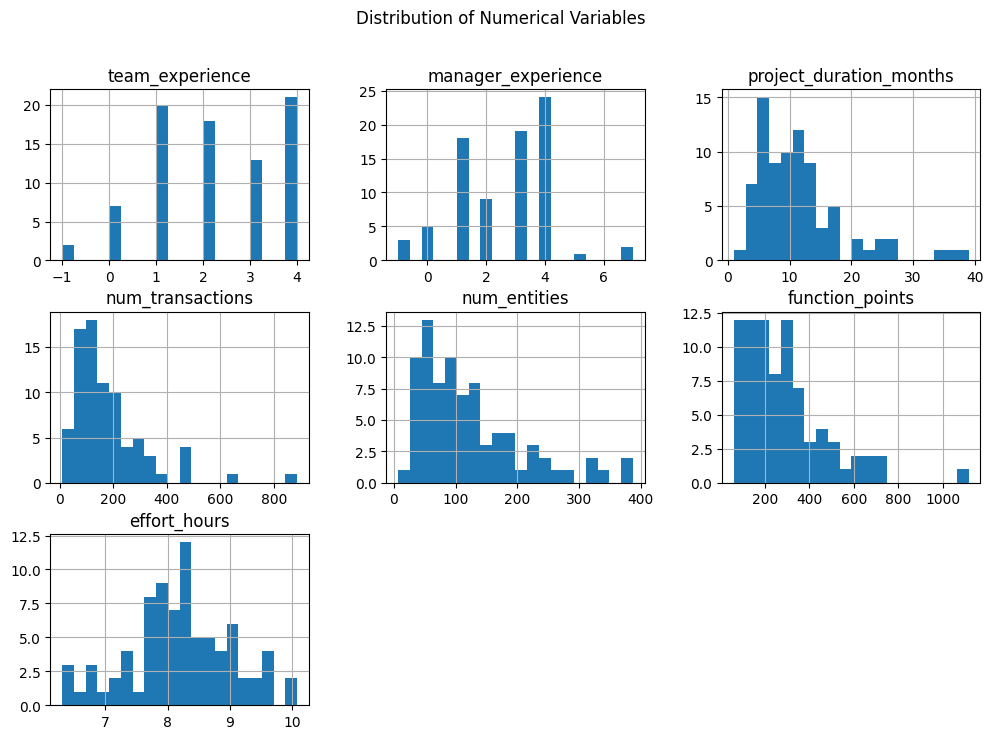

In [128]:
num_cols = [
    "team_experience",
    "manager_experience",
    "project_duration_months",
    "num_transactions",
    "num_entities",
    "function_points",
    "effort_hours"
]

desh[num_cols].hist(figsize=(12,8), bins=20)

plt.suptitle("Distribution of Numerical Variables")
plt.show()

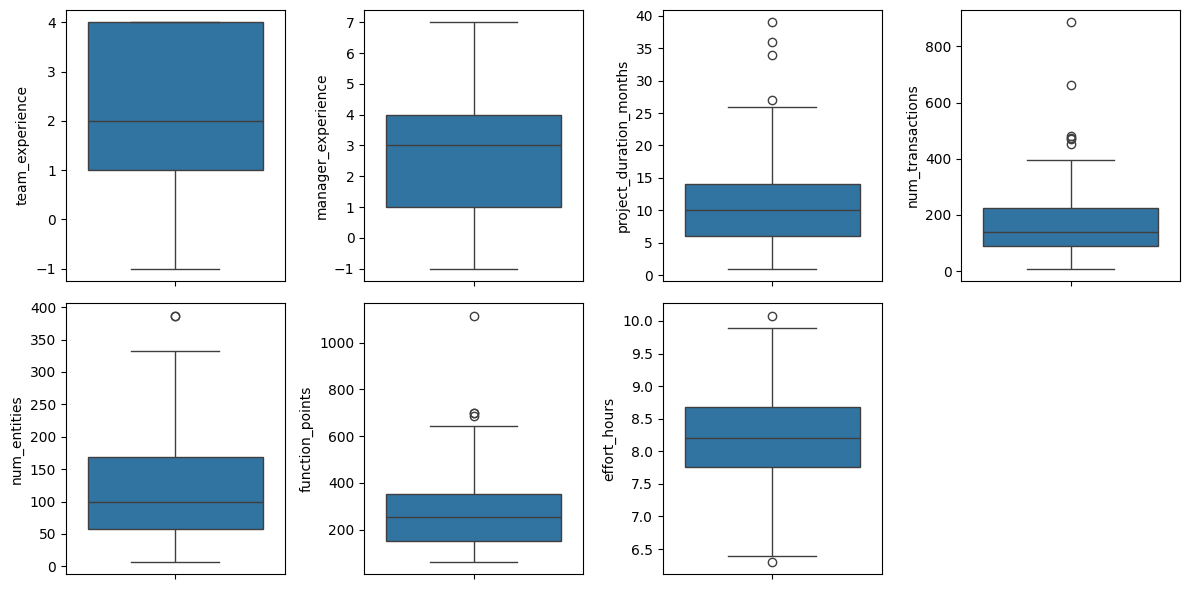

In [129]:
plt.figure(figsize=(12,6))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2,4,i)
    sns.boxplot(y=desh[col])

plt.tight_layout()
plt.show()

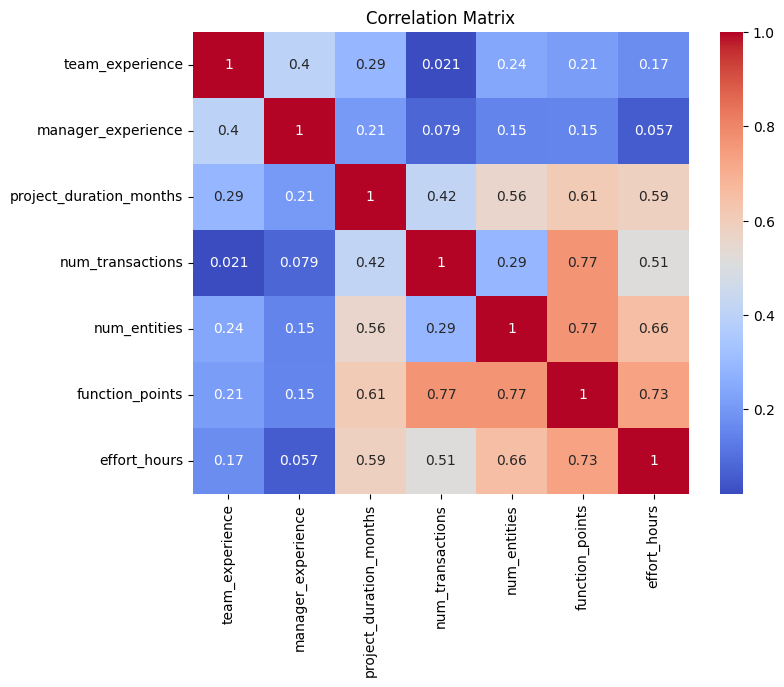

In [130]:
corr = desh[num_cols].corr(method="spearman")

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

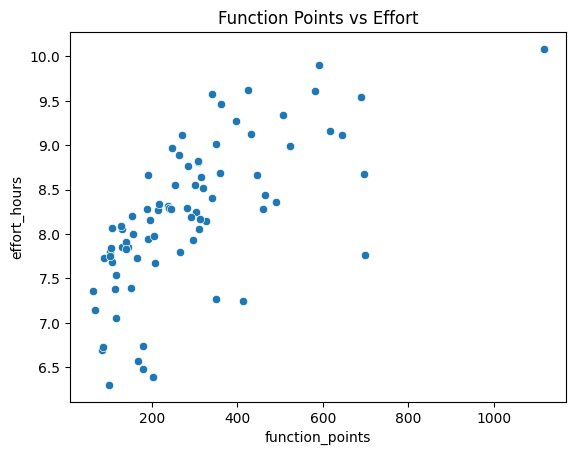

In [131]:
sns.scatterplot(
    x=desh["function_points"],
    y=desh["effort_hours"]
)

plt.title("Function Points vs Effort")
plt.show()

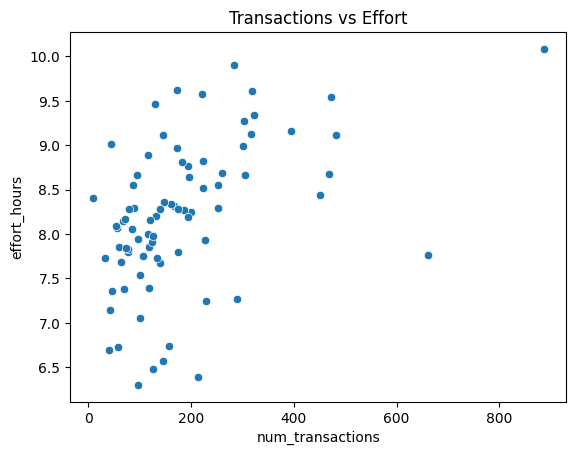

In [132]:
sns.scatterplot(
    x=desh["num_transactions"],
    y=desh["effort_hours"]
)

plt.title("Transactions vs Effort")
plt.show()

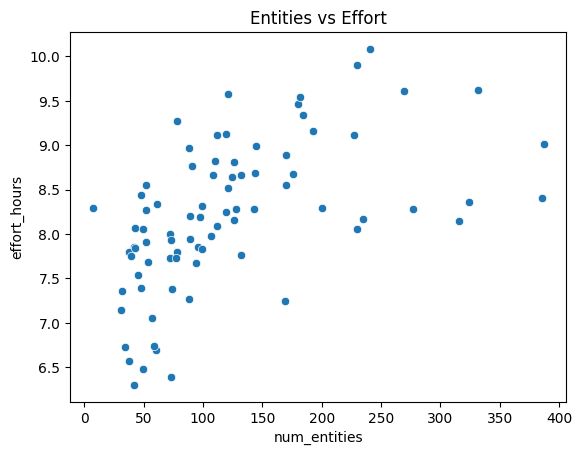

In [133]:
sns.scatterplot(
    x=desh["num_entities"],
    y=desh["effort_hours"]
)

plt.title("Entities vs Effort")
plt.show()

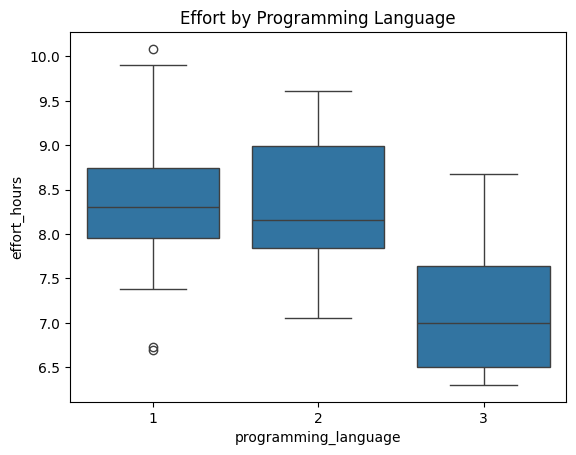

In [134]:
sns.boxplot(
    x=desh["programming_language"],
    y=desh["effort_hours"]
)

plt.title("Effort by Programming Language")
plt.show()

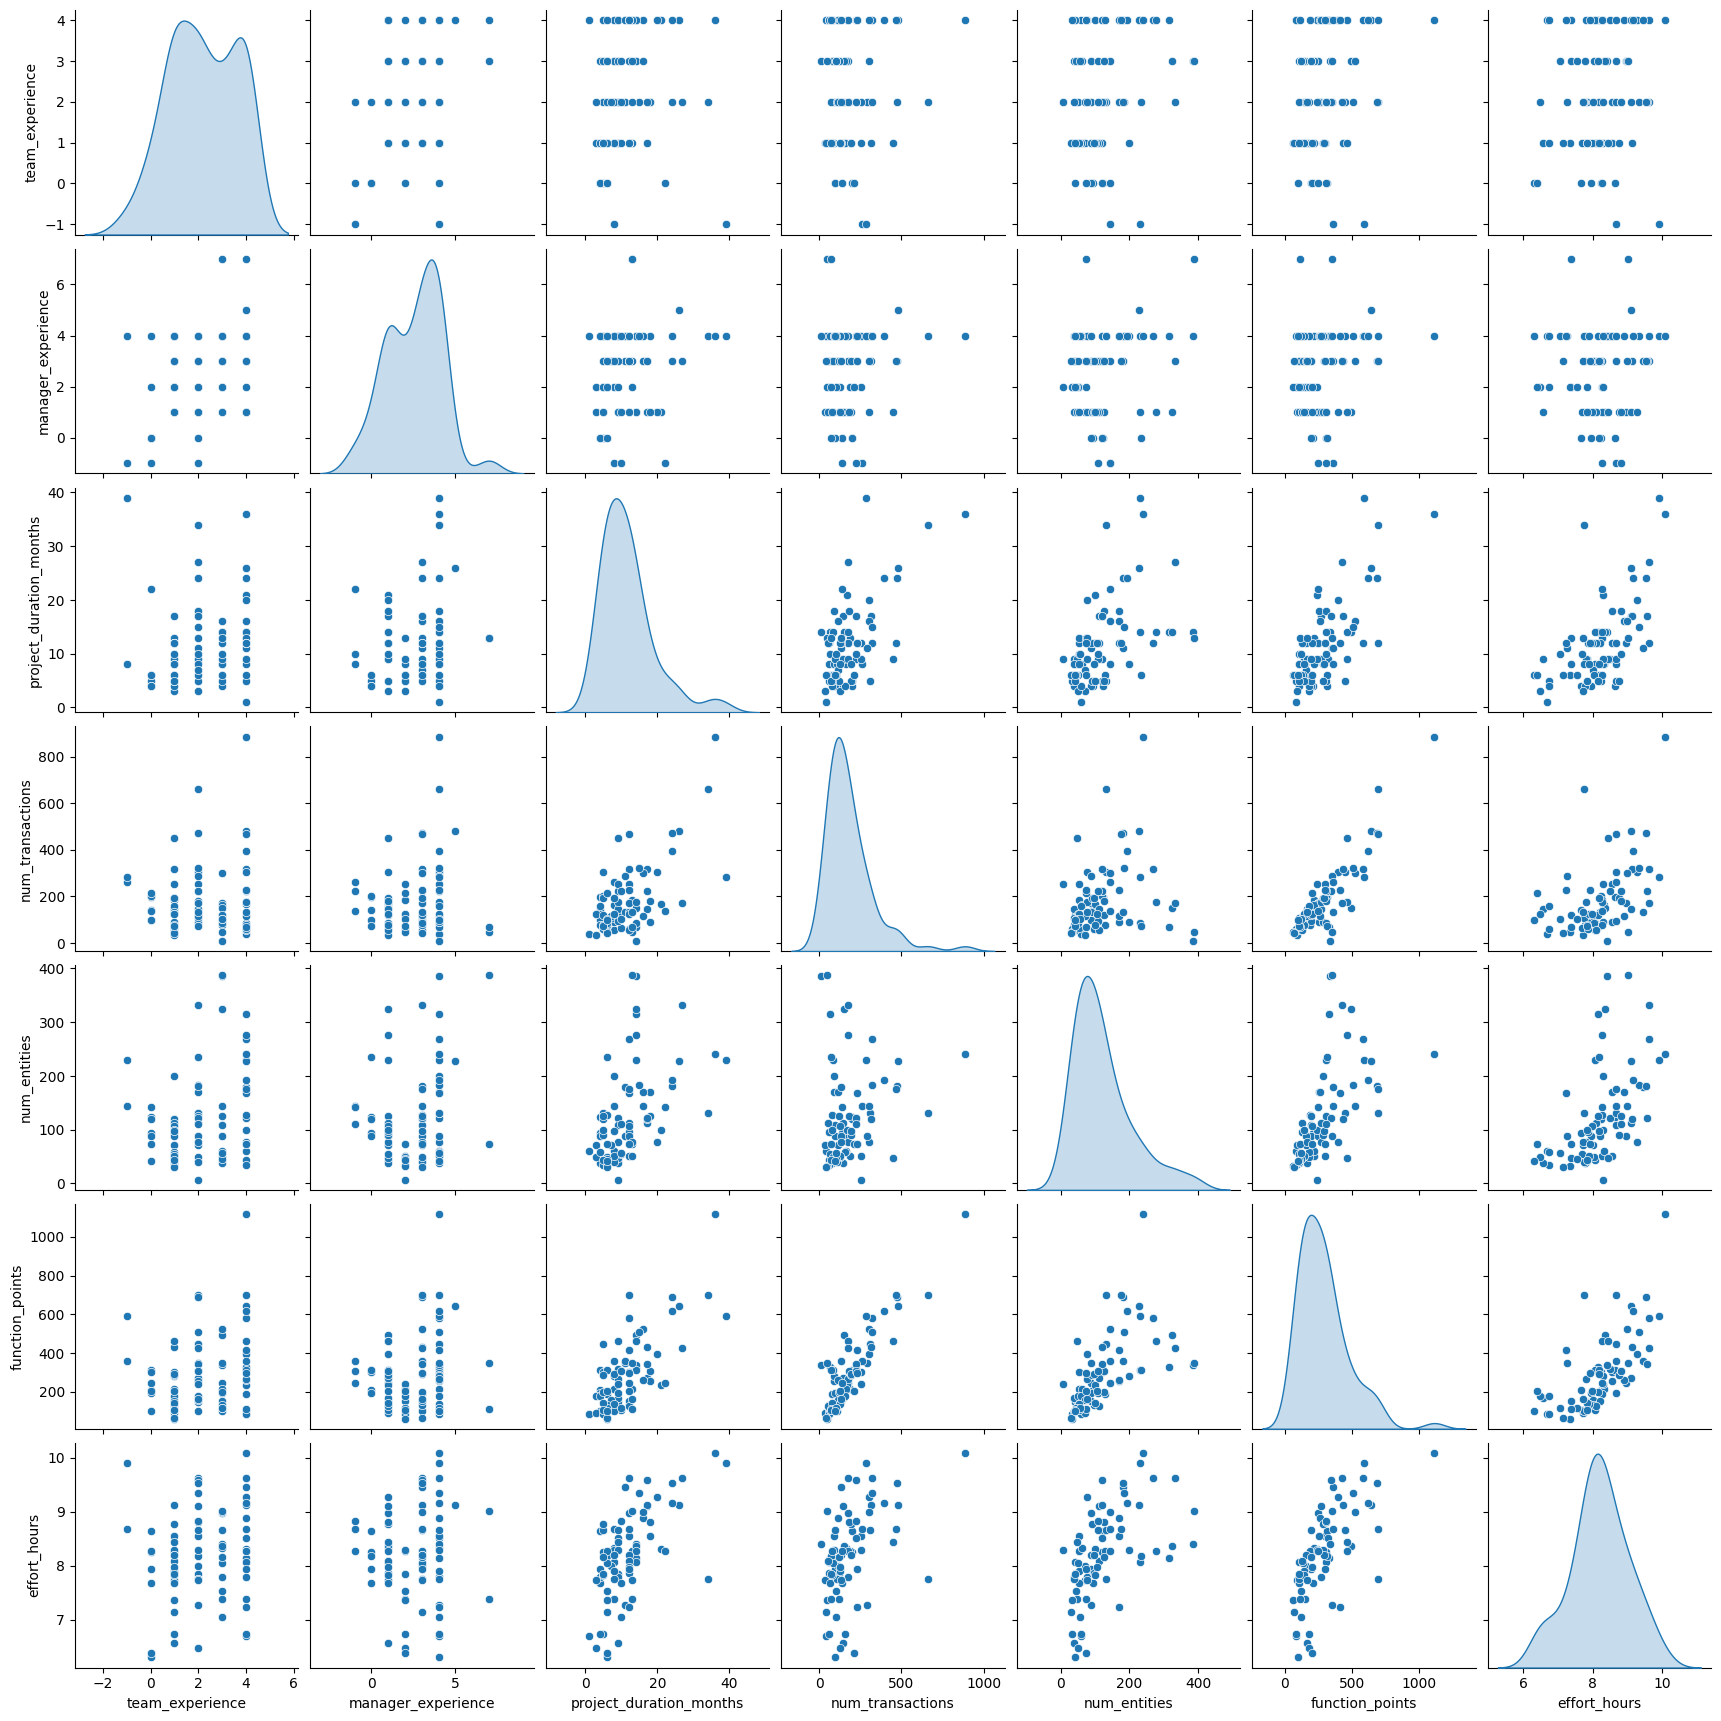

In [135]:
sns.pairplot(
    desh[num_cols],
    diag_kind="kde"
)

In [136]:
desh["productivity"] = desh["effort_hours"] / desh["function_points"]

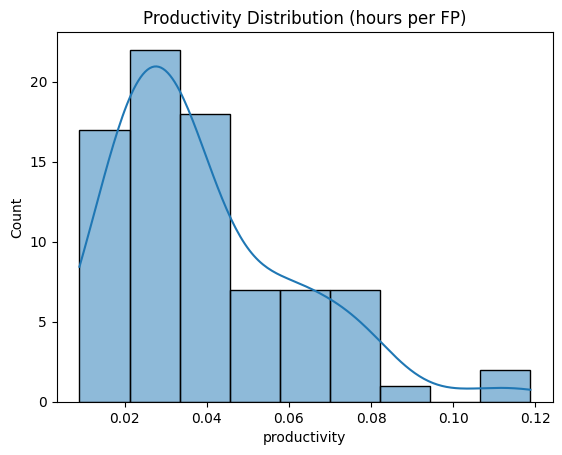

In [137]:
sns.histplot(desh["productivity"], kde=True)

plt.title("Productivity Distribution (hours per FP)")
plt.show()

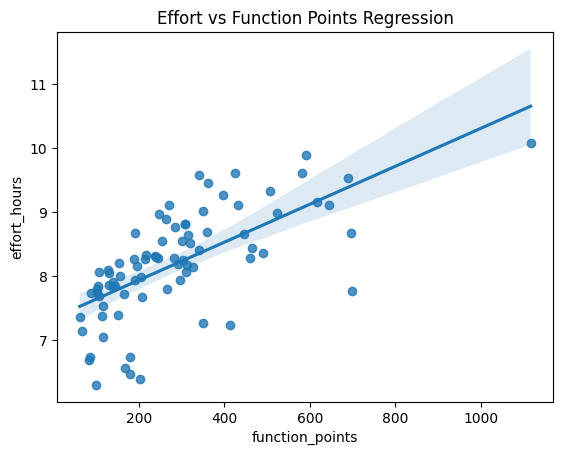

In [138]:
sns.regplot(
    x=desh["function_points"],
    y=desh["effort_hours"]
)

plt.title("Effort vs Function Points Regression")
plt.show()

### Exploração do dataset **Desharnais** (`desh`)

Após a leitura do ficheiro percebemos que o conjunto era pequeno (81 observações, 12 colunas) e sem valores em falta.

1. **Renomeação e limpeza**
    * Colunas com nomes pouco legíveis substituídas por versões descritivas (`TeamExp` → `team_experience`, `Effort` → `effort_hours`, …).
    * Eliminámos `id` e `Project`, que não acrescentavam informação para modelagem.

2. **Tratamento de tipos e engenharia de características**
    * `effort_hours` transformado com `np.log1p` para aproximar a distribuição de uma normal.
    * `programming_language` convertido para `category`.
    * Adicionada variável `productivity` = esforço / pontos de função (horas por FP).

3. **Distribuições univariadas**
    * Histogramas dos sete atributos numéricos (`team_experience`, `manager_experience`, …, `effort_hours`) mostraram dispersão moderada e alguns valores extremos em project_duration e effort.
    * Boxplots confirmaram a presença de outliers em várias colunas e permitiram visualizar diferenças de escala.

4. **Correlação e relações bivariadas**
    * Matriz de correlação (Spearman) entre as variáveis numéricas:
      ```
      effort_hours  correlaciona mais fortemente com 
                         function_points (≈ 0.73), 
                         num_entities (0.66) e 
                         project_duration_months (0.59).
      ```
    * `num_transactions` e `function_points` também muito correlacionados entre si (> 0.76).
    * Scatterplots individuais:
      * `function_points` vs. `effort_hours` exibiu uma relação linear clara (confirmada pelo `regplot`).
      * Relações semelhantes, embora menos firmes, foram observadas com `num_transactions` e `num_entities`.

5. **Efeito da linguagem**
    * Boxplot de `effort_hours` por `programming_language` mostrou dispersão semelhante entre categorias; não há diferença dramática no esforço log-transformado.

6. **Productivity**
    * A distribuição de produtividade (horas por ponto de função) mostrou um pico em valores baixos e uma cauda longa, reforçando heterogeneidade de eficiência entre projetos.

---

**Insights gerais**

* O esforço de desenvolvimento cresce de forma quase linear com o tamanho funcional do projeto; pontos de função são a variável mais preditiva.
* Outros indicadores de dimensão (`num_entities`, `num_transactions`) seguem padrões semelhantes, o que é esperado.
* A transformação logarítmica do esforço tornou as distribuições mais simétricas, facilitando modelagens posteriores.
* A produtividade, embora útil para comparações, apresenta grande variabilidade e poderá ser influenciada por fatores não capturados no dataset.
* Com apenas 81 observações, qualquer modelo construído terá de lidar com amostra limitada; considerações de validação cruzada e regularização serão importantes.

Este resumo sintetiza o conhecimento ganho até ao momento sobre o conjunto `desh` e prepara-nos para passos seguintes de modelagem ou de comparação com o dataset Maxwell.

___

Comparação dos conjuntos `maxx` e `desh` e implicações para previsão
==================================================================

- **Escopo e granularidade**
    * `desh` (Desharnais) é um conjunto de 81 projectos completos. As variáveis
        são de nível de projecto: experiência da equipa/gestor, número de
        transacções, entidades, ano de fim, etc. O target é o esforço total do
        projecto. Útil para estimativas de projecto ou de release, não de
        iterações individuais.
    * `maxx` (Maxwell) foi concebido para estudos de esforço em “sprints”/iterações.
        Depois da limpeza ficam 57 observações e as variáveis incluem
        `development_time`, `function_points`, `technical_complexity` e várias
        categorias técnicas/organizacionais. O target (horas de esforço) refere‑se
        a uma única sprint.

- **Tamanho e qualidade**
    * Ambos são conjuntos pequenos, mas só `maxx` já está no nível de detalhe
        requerido; `desh` teria de ser recomputado ou agregado para servir de base
        a sprints, o que não é natural no problema actual.

- **Adequação para previsão por sprint**
    * Para o exercício de previsão de esforço por sprint, `maxx` é o candidato
        natural. As features que ele contém podem ser, pelo menos em teoria,
        derivadas dos dados de um quadro Trello (por exemplo, pontos de função
        ≃ soma de story points ou contagem de cartões, complexidade técnica ≃
        etiquetas / campos personalizados).
    * `desh` será útil apenas se quisermos estimar esforço de projecto; a
        granularidade é demasiado grosseira para a aplicação pretendida.

- **Possibilidades e tratativas em ambiente de produção**
    1. *Mapeamento de features* – identificar nos dados do Trello colunas ou
         campos que correspondam às variáveis de treino. Se não houver
         `function_points`, criar um proxy (sumário de story points, número de
         cards, análise de texto, etc.). Similarmente, construir `technical_complexity`
         a partir de etiquetas, check‑lists ou outros indicadores de dificuldade.
         Categorias como `application_type`/`database_used` terão de vir de
         listas ou etiquetas; caso não existam, substituir por outras características
         relevantes extraídas dos cartões.
    2. *Pré‑processamento homogéneo* – replicar a engenharia feita em `maxx`: renomear,
         eliminar colunas irrelevantes, calcular somatórios, aplicar `np.log1p`
         ao esforço e escalar com um `StandardScaler` (guardar o scaler e os
         encoders para uso em produção). Tratar NA e outliers (critério IQR).
    3. *Aumentar/atualizar a base* – 57 observações são poucas; ao alimentar
         continuamente com sprints reais do Trello e re‑treinar o modelo ganha‑se
         robustez. Se for possível, acrescentar dados de `desh` apenas como
         referência ou para treino de outro modelo de nível de projecto.
    4. *Validação* – usar validação cruzada/regularização e métricas adequadas
         (MAE, RMSE em escala log) porque o volume de dados é limitado; monitorizar
         predições em produção para detectar deriva e recalibrar.
    5. *Feature engineering adicional* – em vez de confiar cegamente nas
         variáveis existentes, considerar novas features derivadas de Trello,
         como número de cartões por sprint, média de story points, tempo médio
         de ciclo, experiência da equipa (conta dos membros activos), etc.

- **Resumo**
    Para o problema de previsão de esforço por sprint e com a necessidade de
    alimentar o modelo com dados vindos do Trello, o dataset **Maxwell** é o mais
    apropriado. Ele já trabalha na granularidade desejada e, com um pipeline
    de pré‑processamento que transforme as métricas do Trello nas mesmas
    features usadas no treino, permite uma transição direta para produção. O
    conjunto Desharnais pode ser consultado para análises de nível de projecto,
    mas não deve ser usado como base principal na fase de sprint.

Em produção, o fundamental é garantir que as tabelas extraídas da API do
Trello contenham variáveis que sejam, ou possam ser convertidas em, `function_points`,
`development_time`, `technical_complexity` e quaisquer categorias que o
modelo vier a exigir; caso contrário o modelo não receberá entradas compatíveis
com o que aprendeu.